In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("../data/test_1_payment_data/test_1_payment_data.csv")
data.head(3)

,#,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
0,1,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39.000000,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM
1,2,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36.000000,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA
2,3,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32.000000,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.0,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 566413 entries, 0 to 566412
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   #                   566413 non-null  int64  
 1   order_id            566413 non-null  str    
 2   event_time          566413 non-null  str    
 3   user_id             566413 non-null  str    
 4   price               566413 non-null  float64
 5   payment_number      566413 non-null  str    
 6   transaction_status  566413 non-null  str    
 7   card_brand          566413 non-null  str    
 8   card_type           565643 non-null  str    
 9   bank_name           564404 non-null  str    
 10  error_type          313048 non-null  float64
 11  currency            566413 non-null  str    
 12  card_country        565886 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 56.2 MB


In [11]:
miss_data = data.isnull().sum()
miss_data.sum

<bound method Series.sum of #                          0
order_id                   0
event_time                 0
user_id                    0
price                      0
payment_number             0
transaction_status         0
card_brand                 0
card_type                770
bank_name               2009
error_type            253365
currency                   0
card_country             527
dtype: int64>

<Axes: xlabel='card_country', ylabel='count'>

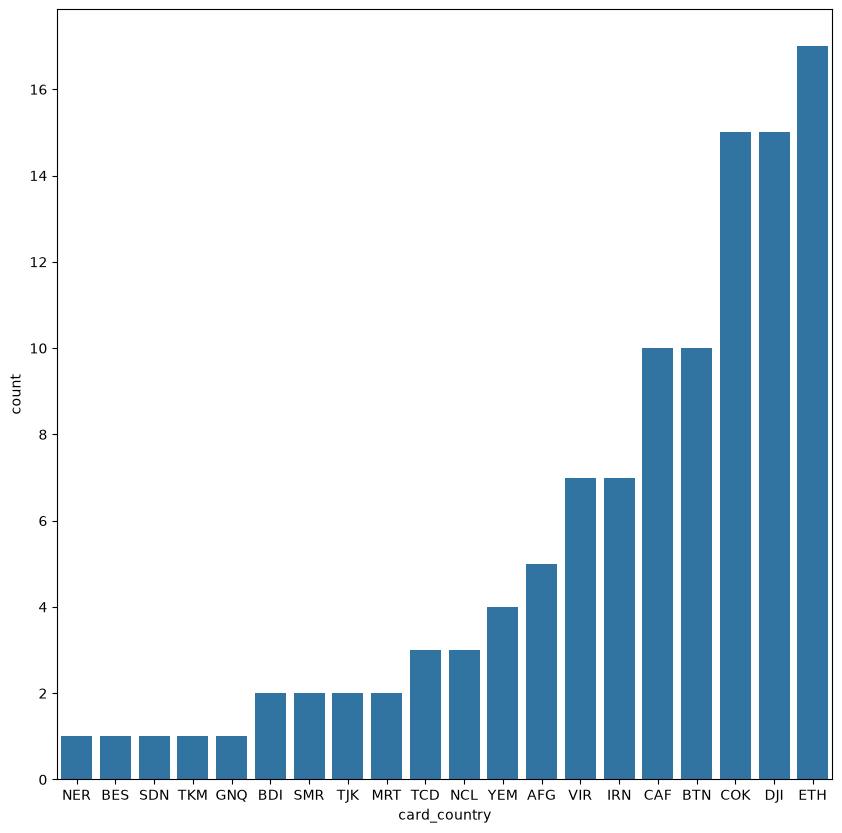

In [23]:
count_country = data['card_country'].value_counts()
plt.figure(figsize = (10,10))
sns.barplot(count_country.sort_values().head(20))

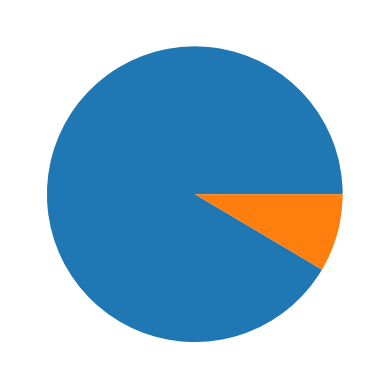

In [26]:
data['currency'].value_counts()
plt.pie(data['currency'].value_counts())

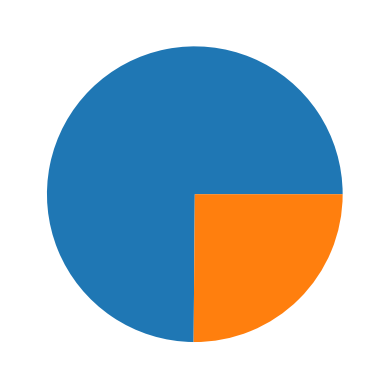

In [29]:
data['payment_number'].value_counts()
plt.pie(data['payment_number'].value_counts())

In [36]:
data.groupby('transaction_status')['price'].sum()

transaction_status
fail       8369595.0
success    5587666.0
Name: price, dtype: float64

In [50]:
data.groupby('transaction_status')['price'].agg(['sum', 'min', 'max', 'mean', 'median'])

,sum,min,max,mean,median
transaction_status,,,,,
fail,8369595.0,4.0,107.0,26.658667,36.0
success,5587666.0,4.0,90.0,22.132964,21.0


In [52]:
data.duplicated().sum()

np.int64(0)

In [58]:
data['event_time'] = pd.to_datetime(data['event_time'])
data['event_time']

0        2022-07-08 18:32:39
1        2022-06-09 22:18:36
2        2022-06-09 11:18:32
3        2022-06-29 13:50:47
4        2022-06-17 15:16:47
                 ...        
566408   2022-04-14 13:23:13
566409   2022-04-17 16:14:47
566410   2022-01-03 08:12:47
566411   2022-05-01 12:47:47
566412   2022-03-18 05:57:37
Name: event_time, Length: 566413, dtype: datetime64[us]

In [76]:
data['hour'] = data['event_time'].dt.hour
data['year'] = data['event_time'].dt.year
data['minute'] = data['event_time'].dt.minute
data['month'] = data['event_time'].dt.month

In [77]:
data.head()

,#,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country,hour,year,minute,month
0,1,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM,18,2022,32,7
1,2,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA,22,2022,18,6
2,3,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.0,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND,11,2022,18,6
3,4,3fd11eed-4236-46aa-8f21-3c1e1a17a1bc,2022-06-29 13:50:47,866c4b2b-0285-43aa-98bd-d60bc3a78d7c,36.0,reccurent,fail,VISA,DEBIT,THE TORONTO-DOMINION BANK,3.02,USD,CAN,13,2022,50,6
4,5,3b19657f-1a34-4233-b25c-5d3b7fb32782,2022-06-17 15:16:47,bd2e4137-5526-4d9b-9dde-7482087fc321,9.0,reccurent,success,MASTERCARD,CREDIT,"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",NaN,USD,USA,15,2022,16,6


In [78]:
data['year'].value_counts()
data['hour'].value_counts().sort_values(ascending=True)

hour
10    18652
8     19743
9     19863
11    20084
23    20553
0     21185
7     21428
12    21809
22    22090
1     22358
6     23595
21    24229
13    24239
2     24982
5     25029
20    25633
19    25674
18    25865
14    25928
17    26621
4     26665
15    26668
3     26723
16    26797
Name: count, dtype: int64

In [79]:
data['card_brand'].value_counts()

card_brand
VISA              362953
MASTERCARD        191957
AMEX                6884
DISCOVER            1912
RUPAY               1575
MAESTRO              537
DINERS CLUB          204
VERVE                203
CHINA UNIONPAY        74
LOCAL BRAND           57
ELO                   24
NSPK MIR              16
PRIVATE LABEL          5
TROY                   4
AIRPLUS                3
ATM CARD               1
EBT                    1
DINACARD               1
INSTAPAYMENT           1
JCB                    1
Name: count, dtype: int64